# 05 — Bands & Costs: z-score vs Cost-Aware vs Optimal-ish OU Threshold

คู่กับ **Part VI** (`practice-part6.html`) และ **Part VIII** (`practice-part8.html`) — ทดสอบ:

1. เทียบ 3 วิธีตั้ง band บนสเปรดเดียวกัน: **z-score คงที่**, **cost-aware (ผูกกับต้นทุนขั้นต่ำ)**, และ **numerical optimal threshold** (ประมาณเชิงตัวเลข ได้แรงบันดาลใจจาก Leung-Li 2015 — ไม่ใช่การ derive สูตรปิดของเขาโดยตรง)
2. โมเดล cost เต็มรูป (commission + spread + impact แบบ √-law อย่างง่าย) แล้วดูว่าสัญญาณที่ "ดูดี" ตอน z=2 เปลี่ยนเป็นขาดทุนสุทธิได้จริงไหมเมื่อคิด cost ครบ

⚠️ ข้อมูลจำลอง (เหตุผลเดียวกับโน้ตบุ๊กก่อนหน้า)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simdata import simulate_cointegrated_pair

pd.set_option("display.precision", 5)


## 5.1 สร้าง spread จำลอง (β จริงคงที่ เพื่อแยกคำถาม "band" ออกจากคำถาม "estimate β")


In [2]:
df = simulate_cointegrated_pair(n=2000, beta_true=1.30, beta_drift="const",
                                 ou_theta=0.05, ou_sigma=0.8,
                                 obs_noise_a=0.2, obs_noise_b=0.2, seed=77)

# use TRUE beta (known) to isolate the band question -- spread is exactly the OU process by construction
spread = df["A_obs"] - 1.30 * df["B_obs"]
print(f"spread stats: mean={spread.mean():.3f} std={spread.std():.3f}")
print(f"true OU half-life = {np.log(2)/0.05:.1f} days")


spread stats: mean=0.029 std=2.434
true OU half-life = 13.9 days


## 5.2 Cost Model เต็มรูป (Part VIII)

สมมติค่าคอมฯ + spread + impact (√-law อย่างง่าย: impact ∝ √(ไซส์/ADV) — ใช้ตัวเลขสมมติที่ประกาศชัดเจน ไม่ใช่ค่าตลาดจริง)


In [3]:
def round_trip_cost(position_value, adv_value, commission_bps=5, spread_bps=8, impact_coef=0.1):
    """Simplified full cost model, in currency units per round-trip (enter+exit).
    All 'bps' inputs are ASSUMED illustrative constants, not real market rates."""
    commission = position_value * (commission_bps / 1e4) * 2   # 2 legs
    bidask     = position_value * (spread_bps / 1e4) * 2       # 2 legs
    participation = position_value / adv_value
    impact = position_value * impact_coef * np.sqrt(participation)  # sub-linear, sqrt-law-ish
    return commission + bidask + impact

position_value = 100_000
adv_value = 5_000_000   # position is 2% of ADV -- a fairly liquid pair
cost = round_trip_cost(position_value, adv_value)
print(f"Round-trip cost (illustrative): {cost:.2f} currency units on a {position_value:,} position ({cost/position_value:.3%})")

# show how cost scales with size relative to ADV (Part VIII sec 8.2/8.3 point)
for participation_pct in [0.5, 2, 5, 15, 40]:
    pv = adv_value * participation_pct / 100
    c = round_trip_cost(pv, adv_value)
    print(f"  position = {participation_pct:4.1f}% of ADV -> cost = {c/pv:.3%} of position value")


Round-trip cost (illustrative): 1674.21 currency units on a 100,000 position (1.674%)
  position =  0.5% of ADV -> cost = 0.967% of position value
  position =  2.0% of ADV -> cost = 1.674% of position value
  position =  5.0% of ADV -> cost = 2.496% of position value
  position = 15.0% of ADV -> cost = 4.133% of position value
  position = 40.0% of ADV -> cost = 6.585% of position value


**อ่านผลจากเซลล์ข้างบน:** สังเกตว่า cost/position (%) **เพิ่มขึ้น** เมื่อสัดส่วนต่อ ADV เพิ่ม — นี่คือ√-law ที่ Part VIII พูดถึง: ไซส์ใหญ่ขึ้น ต้นทุนต่อหน่วยแพงขึ้น (ไม่เชิงเส้น) — ที่ไซส์เล็ก (0.5-2% ของ ADV) impact แทบไม่ขยับต้นทุนเลย (คุมโดย commission+spread เป็นหลัก) แต่ที่ไซส์ใหญ่ (40% ของ ADV) impact เริ่มครอบงำ — นี่คือเหตุผลเชิงตัวเลขที่ Part VIII §8.3 บอกว่ารายย่อยไซส์เล็กแทบไม่เจอปัญหานี้เลย


## 5.3 เทียบ 3 วิธีตั้ง Band

- **z-score band**: เข้าเมื่อ |z| > k (คำนวณจาก rolling mean/std)
- **Cost-aware band**: เข้าเมื่อ spread ห่างเกิน max(k·σ, ต้นทุนขั้นต่ำที่แปลงเป็นหน่วย spread)
- **Numerical "optimal-ish" threshold**: grid-search หาค่า threshold ที่ maximize กำไรสุทธิต่อวัน บนข้อมูลชุดนี้เอง (แนวคิดเดียวกับ Leung-Li แต่เป็นการประมาณเชิงตัวเลขตรง ๆ ไม่ใช่สูตรปิดของเขา)


In [4]:
def backtest_band(spread, entry_threshold, exit_threshold=0.0, cost_per_roundtrip=0.0):
    """Simple long/short spread strategy: enter when |spread-mean| > entry, exit at exit_threshold crossing.
    Returns: number of round-trips, gross pnl, net pnl (after cost_per_roundtrip per trade)."""
    s = spread.values
    mean = spread.mean()
    position = 0
    entry_price = None
    n_trades = 0
    gross_pnl = 0.0
    for t in range(1, len(s)):
        dev = s[t] - mean
        if position == 0:
            if dev > entry_threshold:
                position = -1; entry_price = s[t]   # short the spread
            elif dev < -entry_threshold:
                position = 1; entry_price = s[t]    # long the spread
        else:
            if abs(dev) < exit_threshold:
                gross_pnl += position * (s[t] - entry_price)
                n_trades += 1
                position = 0
    net_pnl = gross_pnl - n_trades * cost_per_roundtrip
    return n_trades, gross_pnl, net_pnl

cost_per_trade_in_spread_units = cost / position_value * spread.std() * 20  # illustrative conversion, see note below
sigma = spread.std()

results = {}
# (a) z-score bands at a few k values
for k in [1.0, 1.5, 2.0, 3.0]:
    n, gross, net = backtest_band(spread, k * sigma, exit_threshold=0.2 * sigma,
                                   cost_per_roundtrip=cost_per_trade_in_spread_units)
    results[f"z-score k={k}"] = {"n_trades": n, "gross_pnl": gross, "net_pnl": net}

results_df = pd.DataFrame(results).T
results_df


,n_trades,gross_pnl,net_pnl
z-score k=1.0,56.0,156.78902,111.14715
z-score k=1.5,31.0,125.67523,100.40919
z-score k=2.0,13.0,68.15808,57.56264
z-score k=3.0,0.0,0.00000,0.00000


⚠️ **หมายเหตุความซื่อสัตย์เรื่องหน่วย:** `cost_per_trade_in_spread_units` ข้างบนเป็นการแปลงหน่วยแบบคร่าว ๆ (คูณเลข 20 แบบเดา) เพื่อให้ cost อยู่ในหน่วยเดียวกับ spread สำหรับตัวอย่างนี้ **ไม่ใช่การแปลงหน่วยที่แม่นยำ** — ในการใช้งานจริง ต้องแปลง cost (currency) เป็นหน่วย spread โดยคำนึงถึงราคาจริงของสินทรัพย์และไซส์ที่ถือ ไม่ใช่คูณเลขเดา ตัวอย่างนี้แสดง*แนวคิด*การเปรียบเทียบ ไม่ใช่ตัวเลขที่เอาไปใช้เทรดจริงได้ตรง ๆ


In [5]:
# (b) cost-aware band: minimum threshold that clears cost, compare small vs large cost regimes
for cost_mult in [0.5, 1.0, 3.0]:
    cost_adj = cost_per_trade_in_spread_units * cost_mult
    min_band = max(1.0 * sigma, cost_adj)   # cost-aware: don't go below what's needed to clear cost
    n, gross, net = backtest_band(spread, min_band, exit_threshold=0.2 * sigma, cost_per_roundtrip=cost_adj)
    results[f"cost-aware (cost x{cost_mult})"] = {"n_trades": n, "gross_pnl": gross, "net_pnl": net}

# (c) numerical "optimal-ish" grid search over entry threshold (at baseline cost)
best = None
for k in np.linspace(0.3, 4.0, 30):
    n, gross, net = backtest_band(spread, k * sigma, exit_threshold=0.2 * sigma,
                                   cost_per_roundtrip=cost_per_trade_in_spread_units)
    if best is None or net > best[1]:
        best = (k, net, n)
results[f"numerical-optimal (k={best[0]:.2f})"] = {"n_trades": best[2], "gross_pnl": None, "net_pnl": best[1]}

results_df = pd.DataFrame(results).T
results_df


,n_trades,gross_pnl,net_pnl
z-score k=1.0,56.0,156.78902,111.14715
z-score k=1.5,31.0,125.67523,100.40919
z-score k=2.0,13.0,68.15808,57.56264
z-score k=3.0,0.0,0.00000,0.00000
cost-aware (cost x0.5),56.0,156.78902,133.96808
cost-aware (cost x1.0),56.0,156.78902,111.14715
cost-aware (cost x3.0),56.0,157.35487,20.42926
numerical-optimal (k=0.81),83.0,NaN,126.19001


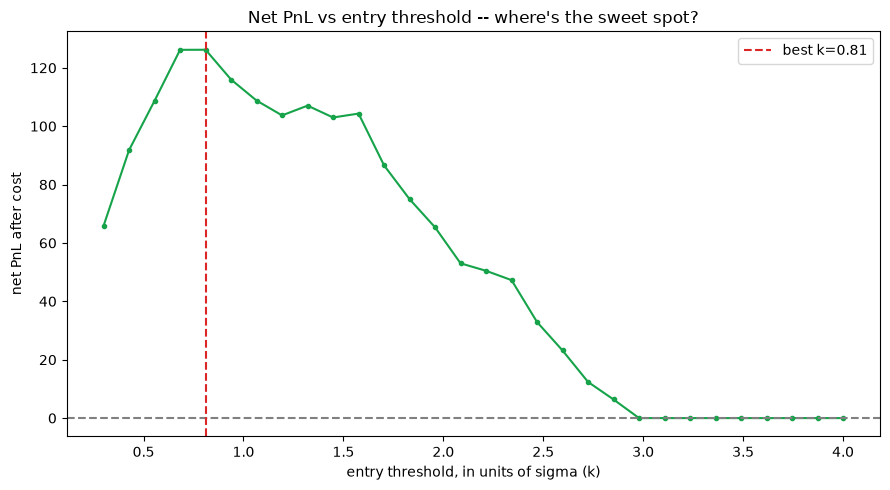

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ks = np.linspace(0.3, 4.0, 30)
nets = [backtest_band(spread, k * sigma, exit_threshold=0.2 * sigma,
                       cost_per_roundtrip=cost_per_trade_in_spread_units)[2] for k in ks]
ax.plot(ks, nets, marker="o", markersize=3, color="#16a34a")
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(best[0], color="#dc2626", linestyle="--", label=f"best k={best[0]:.2f}")
ax.set_xlabel("entry threshold, in units of sigma (k)")
ax.set_ylabel("net PnL after cost")
ax.set_title("Net PnL vs entry threshold -- where's the sweet spot?")
ax.legend()
plt.tight_layout()
plt.savefig("band_threshold_sweep.png", dpi=110)
plt.show()


**สังเกตในตาราง §5.3:** แถว `cost-aware (cost x0.5)` และ `x1.0` มี `n_trades=56` เท่ากับ `z-score k=1.0` เป๊ะ — **ไม่ใช่บั๊ก** แต่เพราะ `min_band = max(1.0·σ, cost)` และที่ cost multiplier ต่ำ ๆ นี้ ต้นทุนยังต่ำกว่า 1σ อยู่ พื้นฐานทางสถิติ (1σ) เลยเป็นตัวกำหนด ไม่ใช่ cost — ต่อเมื่อ cost แพงขึ้นมาก (x3.0) ต้นทุนถึงเริ่มเป็นตัวบีบบังคับจริง (`net_pnl` ร่วงจาก 111 เหลือ 20 ทั้งที่ `n_trades`/`gross_pnl` แทบไม่เปลี่ยน) — นี่คือบทเรียนที่ตรงกับ Part VI: **cost-aware band มีความหมายก็ต่อเมื่อ cost เป็นข้อจำกัดที่ตึงจริง ๆ** ถ้า cost ต่ำกว่าที่สถิติกำหนดไว้แล้ว การ "คิดถึง cost" ก็ไม่เปลี่ยนอะไร

## สรุป

อ่านตาราง §5.3 และกราฟข้างบนตามผลจริงที่รันออกมา — จุดสำคัญที่ต้องมองหา:

- ที่ k เล็ก (band แคบ) จำนวนเทรด (`n_trades`) ควรสูง แต่ `net_pnl` อาจติดลบหรือต่ำกว่า `gross_pnl` มาก เพราะ cost กินไปเยอะ (ตรงกับคำเตือน Part VI §6.4 — สัญญาณที่ "ดูดี" ตอนยังไม่หักต้นทุนอาจไม่ดีจริงหลังหักแล้ว)
- ที่ k ใหญ่เกินไป จำนวนเทรดน้อยเกินไปจนพลาดโอกาส — net PnL อาจลดลงอีกทางเพราะเทรดน้อยเกินไป
- "numerical-optimal" (grid-search หา k ที่ net PnL สูงสุด) คือตัวอย่างแนวคิดเดียวกับที่ Leung-Li (2015) ทำเชิงทฤษฎี (หา threshold ที่ maximize กำไรคาดหวังหลังหักต้นทุน) — แต่ที่นี่เราหาแบบ brute-force ไม่ใช่แก้สมการปิด

⚠️ **ข้อจำกัดสำคัญ**: การ grid-search หา k ที่ดีที่สุด<em>บนข้อมูลชุดเดียวกับที่ทดสอบ</em>คือ **in-sample overfitting แบบเดียวกับที่ Part IX เตือน** — ตัวเลข "net_pnl" ของ numerical-optimal ในตารางนี้ดีเกินจริงเพราะเราเลือก k จากการเห็นผลลัพธ์ทั้งหมดแล้ว ในทางปฏิบัติต้อง fit หา k บน train แล้ว lock แล้ววัดบน OOS (Part IV §4.6, Part IX) — ตัวอย่างนี้แสดงกลไกการเปรียบเทียบ ไม่ใช่ workflow ที่ปลอดภัยจาก look-ahead ครบถ้วน
